In [10]:
%load_ext autoreload
%autoreload 2

In [11]:
from model_deployment_code import *

In [219]:
def parse_array_from_string(s):
    # Remove brackets and split by whitespace
    s = s.strip().replace("[","").replace("]","")
    return np.array([float(v) for v in s.split()], dtype=float)

cols_to_normalize = ['x', 'y', 'Ma', 'Re', 'AOA', 'CL', 'CD']

max_values={}
min_values={}

for col in cols_to_normalize:
    if col == 'y':
        # Convert each row to a numeric array
        database_denormalised[col] = database_denormalised[col].apply(lambda x: parse_array_from_string(x) if isinstance(x, str) else np.array(x, dtype=float))

        # Compute global min and max across all y elements
        y_max = database_denormalised[col].apply(np.max).max()
        y_min = database_denormalised[col].apply(np.min).min()

        # Normalize
        database_denormalised[col] = database_denormalised[col].apply(lambda arr: (arr - y_min) / (y_max - y_min))
        
        max_values[col] = y_max
        min_values[col] = y_min
    
    elif col == 'x':
        # Convert each row to a numeric array
        database_denormalised[col] = database_denormalised[col].apply(lambda x: parse_array_from_string(x) if isinstance(x, str) else np.array(x, dtype=float))

        # Compute global min and max across all y elements
        x_max = database_denormalised[col].apply(np.max).max()
        x_min = database_denormalised[col].apply(np.min).min()

        # Normalize
        database_denormalised[col] = database_denormalised[col].apply(lambda arr: (arr - x_min) / (x_max - x_min))
        
        max_values[col] = x_max
        min_values[col] = x_min
    
    else:
        col_min = database_denormalised[col].min()
        col_max = database_denormalised[col].max()
        database_denormalised[col] = (database_denormalised[col] - col_min) / (col_max - col_min)
        max_values[col] = col_max
        min_values[col] = col_min
# database_denormalised.to_csv('aerofoil_data_normalised_256.csv')

print('max:', max_values)
print('min:', min_values)

# row = {}

# for col in cols_to_normalize:
#     row[f"{col}_max"] = max_values[col]
#     row[f"{col}_min"] = min_values[col]

# df_min_max = pd.DataFrame([row])
# df_min_max.to_csv("min_max_256.csv", index=False)

max: {'x': 1.01, 'y': 0.2655612, 'Ma': 0.6, 'Re': 350000, 'AOA': 10.0, 'CL': 1.9996, 'CD': 0.05}
min: {'x': -0.009702712, 'y': -0.1618754, 'Ma': 0.0, 'Re': 200000, 'AOA': 0.0, 'CL': -0.0, 'CD': 0.00285}


In [206]:
def parse_array_from_string(s):

    s = s.strip().replace("[", "").replace("]", "")
    return np.array([float(v) for v in s.split()])



database = pd.read_csv("aerofoil_data_256.csv")


# ==============================================================
# 1. FILTER DATA
# ==============================================================
# Conditions
CL_min, CL_max = 0.0, 2.0
CD_min, CD_max = 0.0, 0.05

database_clean = database[
    (database["CL"] >= CL_min) & (database["CL"] <= CL_max) &
    (database["CD"] >= CD_min) & (database["CD"] <= CD_max)
].copy()

database_clean.to_csv("aerofoil_data_clean.csv", index=False)
print("Saved aerofoil_data_clean.csv")


# ==============================================================
# 2. NORMALIZE CLEAN DATA
# ==============================================================
cols_to_normalize = ['y', 'Ma', 'Re', 'AOA', 'CL', 'CD']

max_values = {}
min_values = {}

# We work on a copy to avoid accidental corruption
df_norm = database_clean.copy()

for col in cols_to_normalize:

    if col == 'y':
        # Parse array-like column
        df_norm[col] = df_norm[col].apply(parse_array_from_string)

        # Compute global min/max across concatenated arrays
        y_max = df_norm[col].apply(np.max).max()
        y_min = df_norm[col].apply(np.min).min()

        # Normalize each array
        df_norm[col] = df_norm[col].apply(lambda arr: (arr - y_min) / (y_max - y_min))

        max_values[col] = y_max
        min_values[col] = y_min

    else:
        col_min = df_norm[col].min()
        col_max = df_norm[col].max()

        # Min-max normalization
        df_norm[col] = (df_norm[col] - col_min) / (col_max - col_min)

        max_values[col] = col_max
        min_values[col] = col_min


# Save normalized dataset
df_norm.to_csv("aerofoil_data_clean_normalised.csv", index=False)
print("Saved aerofoil_data_clean_normalised.csv")


row = {}
for col in cols_to_normalize:
    row[f"{col}_max"] = max_values[col]
    row[f"{col}_min"] = min_values[col]

df_minmax = pd.DataFrame([row])
df_minmax.to_csv("min_max_clean.csv", index=False)
print("Saved min_max_clean.csv")

print(df_minmax)


Saved aerofoil_data_clean.csv
Saved aerofoil_data_clean_normalised.csv
Saved min_max_clean.csv

=== Normalization ranges ===
      y_max     y_min  Ma_max  Ma_min  Re_max  Re_min  AOA_max  AOA_min  \
0  0.265561 -0.161875     0.6     0.0  350000  200000     10.0      0.0   

   CL_max  CL_min  CD_max   CD_min  
0  1.9996    -0.0    0.05  0.00285  


Model Code raw_coordinates_ResNet_UNet_64_5_4_with_100_epochs
Total parameters: 61,785,986
30 sampling steps
There is no output from xfoil. Possibly because the profile generated is not feasible.


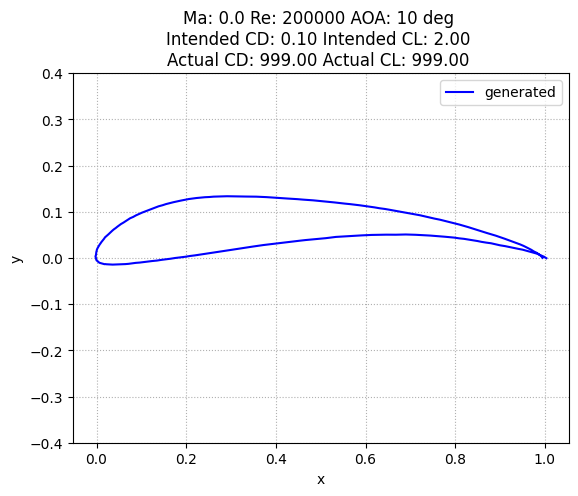

In [20]:
model_deployment(mode = 'test', model_config_path='mdl_hyperparams/raw_coords_conv1d_deep_unet.yaml', sample_number=1, 
                 AOA=10, Ma=0, Re=200000, CL=2.0, CD=0.1,num_steps=30)

In [ ]:
model_deployment(mode = 'test', model_config_path='mdl_hyperparams/raw_coords_conv1d_deep_unet.yaml', sample_number=1, 
                 AOA=0, Ma=0, Re=200000, CL=0.5, CD=0.1,num_steps=30)

Model Code sdf_ResNet_UNet_2D_64_3_4_with_100_epochs
Total parameters: 100,625,665
30 sampling steps


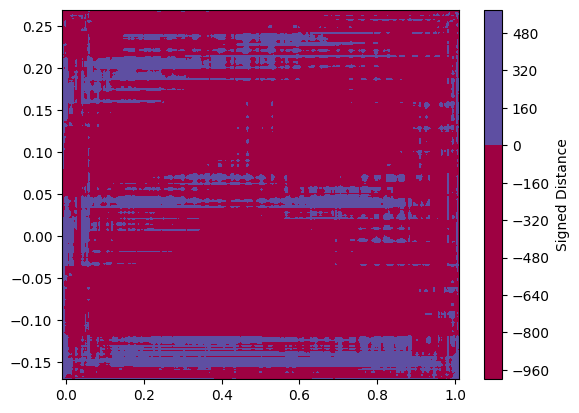

In [16]:
model_deployment(mode = 'validation', model_config_path='mdl_hyperparams/sdf_conv2d_unet.yaml', sample_number=1, num_steps=30, lim = 0.5)

Model Code pca_ResNet_UNet_64_5_4_with_100_epochs
Total parameters: 61,785,601
30 sampling steps


/tmp/ipykernel_143813/877453697.py:106: RuntimeWarning: divide by zero encountered in scalar divide
  if abs((df2['CL'].iloc[idx] - CL)/df2['CL'].iloc[idx]) <=0.01:
/tmp/ipykernel_143813/877453697.py:114: RuntimeWarning: divide by zero encountered in scalar divide
  if abs((df2['CL'].iloc[idx] - CL_actual)/df2['CL'].iloc[idx]) <=0.01:


Same intended conditions in validation set s4110.dat in the validation set.


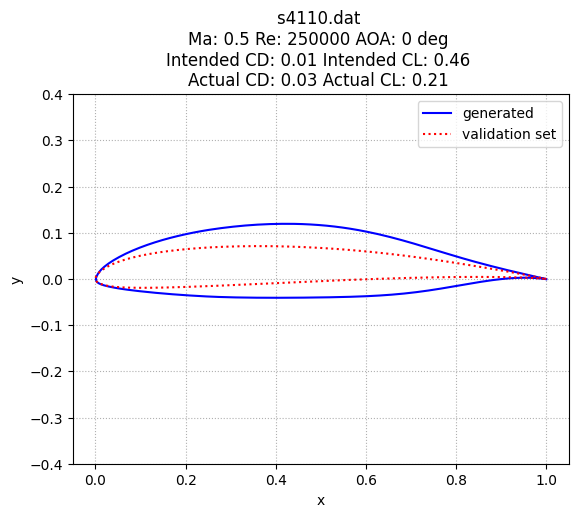

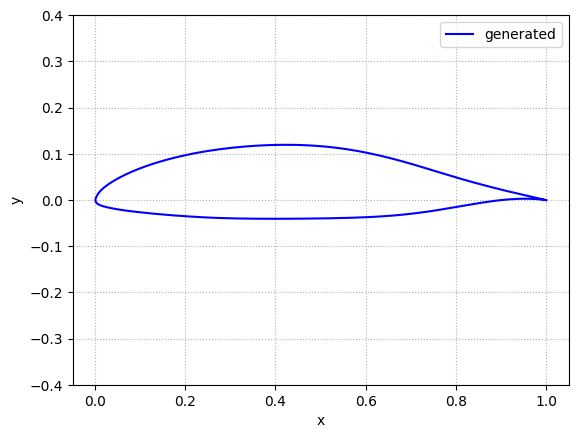

In [68]:
model_deployment(mode = 'validation', model_config_path='mdl_hyperparams/pca_unet.yaml', sample_number=1, num_steps=30)

Model Code raw_coordinates_ResNet_UNet_64_5_4_with_100_epochs
Total parameters: 61,785,986
exe 345
30 sampling steps
There is no output from xfoil. Possibly because the profile generated is not feasible.
Same intended conditions in validation set e432.dat in the validation set.


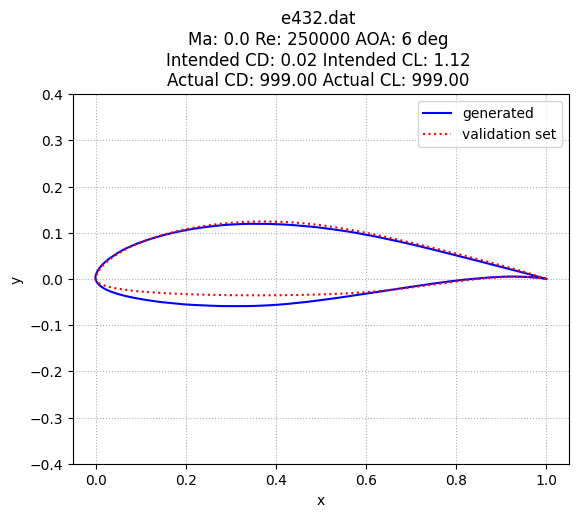

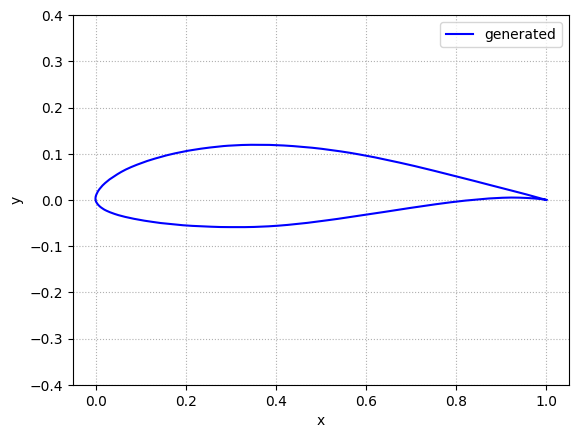

In [71]:
model_deployment(mode = 'validation', model_config_path='mdl_hyperparams/raw_coords_conv1d_deep_unet.yaml', sample_number=1,  num_steps=30, manual_seed=345)

Model Code pca_MLP_128_5_4_with_100_epochs
Total parameters: 34,081,940
30 sampling steps


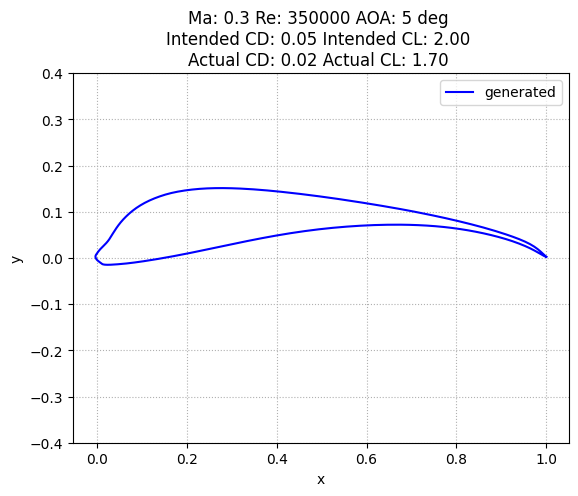

In [115]:
model_deployment(mode = 'test', model_config_path='mdl_hyperparams/pca_mlp.yaml', sample_number=None, AOA=5, Ma=0.3, Re=350000, CL=2, CD=0.05, num_steps=30)

Model Code raw_coordinates_ResNet_UNet_64_5_4_with_100_epochs
Total parameters: 61,785,986
18 sampling steps


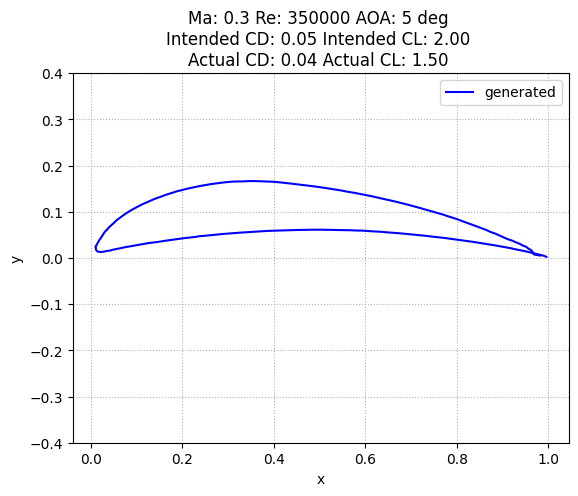

In [223]:
model_deployment(mode = 'test', model_config_path='mdl_hyperparams/raw_coords_conv1d_deep_unet.yaml', sample_number=None, AOA=5, Ma=0.3, Re=350000, CL=2, CD=0.05, num_steps=18)

/tmp/ipykernel_746198/1112432024.py:37: RuntimeWarning: divide by zero encountered in divide
  CL_error = (CL - CL_actual)/CL


Outlier in CL
Outlier in CL
Outlier in CL
Outlier in CL
Outlier in CL
The validation takes 745 samples, among which 182 (24.43%) designs are unfeasible
The accuracy information of the 563 feasible designs are shown below:
CL RMSE is: 0.06652940887162359
CD RMSE is: 0.10189068864202114
87% samples have CL within 10% relative error.
76% samples have CD within 10% relative error.


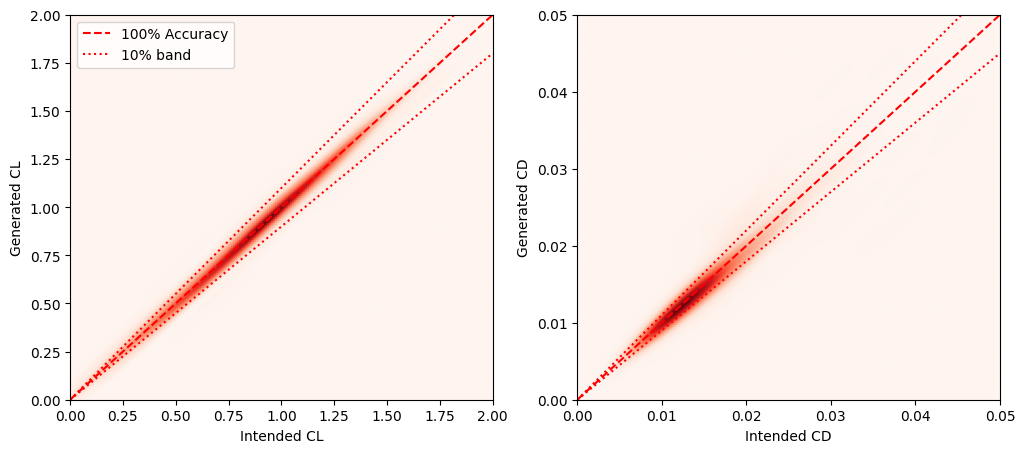

CL best-fit-line gradient is: 0.9895840293014199
CD best-fit-line gradient is: 0.9520554463872919


In [10]:
validation_accuracy(model_config_path='mdl_hyperparams/raw_coords_conv1d_deep_unet.yaml', band = 0.1, mode = 'heatmap', CL_axis_min=0, CL_axis_max=2, CD_axis_min=0, CD_axis_max=0.05)

/tmp/ipykernel_746198/1112432024.py:37: RuntimeWarning: divide by zero encountered in divide
  CL_error = (CL - CL_actual)/CL


Outlier in CL
Outlier in CL
Outlier in CL
Outlier in CL
Outlier in CL
The validation takes 745 samples, among which 182 (24.43%) designs are unfeasible
The accuracy information of the 563 feasible designs are shown below:
CL RMSE is: 0.06652940887162359
CD RMSE is: 0.10189068864202114
87% samples have CL within 10% relative error.
76% samples have CD within 10% relative error.


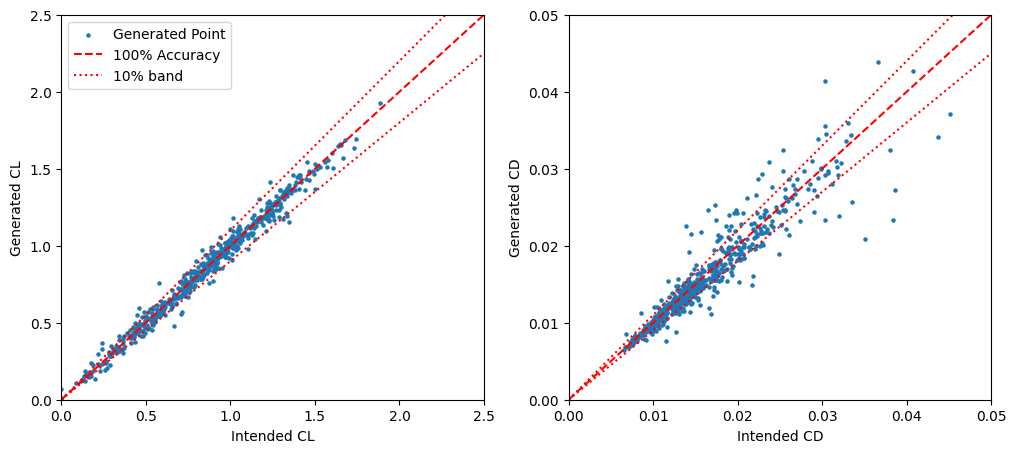

CL best-fit-line gradient is: 0.9895840293014199
CD best-fit-line gradient is: 0.9520554463872919


In [9]:
validation_accuracy(model_config_path='mdl_hyperparams/raw_coords_conv1d_deep_unet.yaml', band = 0.1, mode = 'scatter', CL_axis_min=0, CL_axis_max=2.5, CD_axis_min=0, CD_axis_max=0.05)

The validation takes 771 samples, among which 203 (26.33%) designs are unfeasible
The accuracy information of the 568 feasible designs are shown below:
CL RMSE is: 0.12153290550821845
CD RMSE is: 0.10595321391576253
83% samples have CL within 10% relative error.
73% samples have CD within 10% relative error.


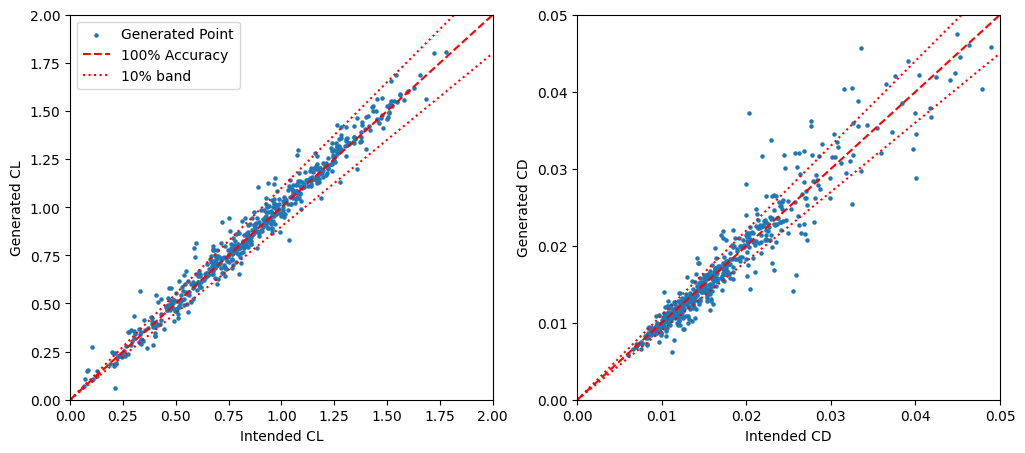

CL best-fit-line gradient is: 1.002804164272837
CD best-fit-line gradient is: 0.9965511609199269


In [204]:
validation_accuracy(model_config_path='mdl_hyperparams/pca_unet.yaml', band = 0.1, mode = 'scatter', CL_axis_min=0, CL_axis_max=2, CD_axis_min=0, CD_axis_max=0.05)

The validation takes 771 samples, among which 203 (26.33%) designs are unfeasible
The accuracy information of the 568 feasible designs are shown below:
CL RMSE is: 0.12153290550821845
CD RMSE is: 0.10595321391576253
83% samples have CL within 10% relative error.
73% samples have CD within 10% relative error.


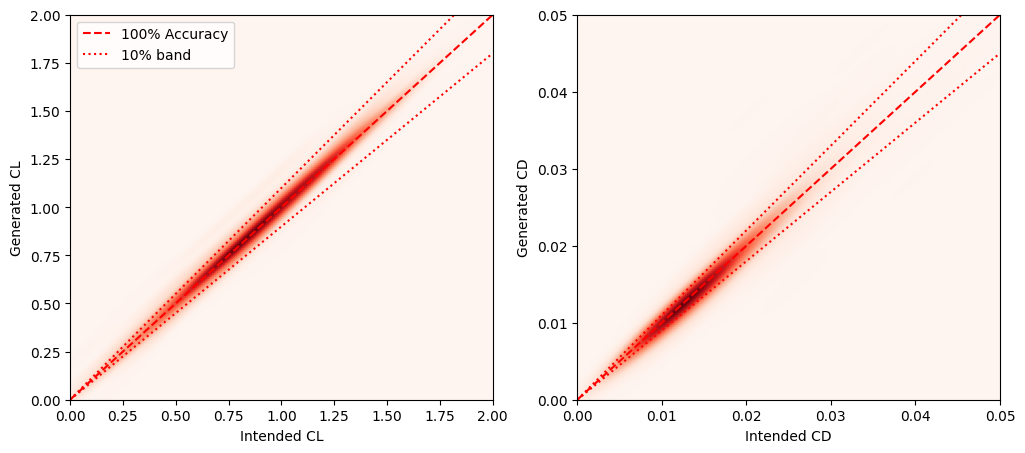

CL best-fit-line gradient is: 1.002804164272837
CD best-fit-line gradient is: 0.9965511609199269


In [205]:
validation_accuracy(model_config_path='mdl_hyperparams/pca_unet.yaml', band = 0.1, mode = 'heatmap', CL_axis_min=0, CL_axis_max=2, CD_axis_min=0, CD_axis_max=0.05)

In [70]:
model_deployment(mode = 'denoise_process_plot', model_config_path='mdl_hyperparams/raw_coords_conv1d_deep_unet.yaml', sample_number=1,  num_steps=30, fig_size=(6,6))

Model Code raw_coordinates_ResNet_UNet_64_5_4_with_100_epochs
Total parameters: 61,785,986
30 sampling steps


/tmp/ipykernel_113371/194742077.py:112: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  writer.append_data(imageio.imread(frame))


GIF saved as: denoising_gif/denoising_process_raw_coordinates_30.gif


In [ ]:
df = pd.read_csv('aerofoil_data_clean_normalised.csv')

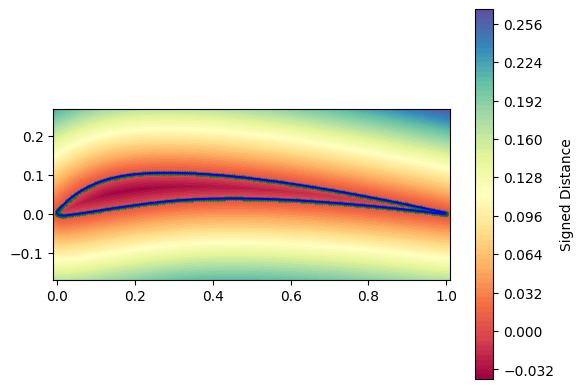

In [228]:
import pandas as pd
import numpy as np
from shapely.geometry import Point, Polygon
import matplotlib.pyplot as plt

idx = 5

x_resolution = 256
y_resolution = 256
x_lower_lim = -0.01
x_upper_lim = 1.01
y_lower_lim = -0.17
y_upper_lim = 0.27

x_str = df.loc[idx, 'x']
x_str = re.sub(r'[\[\]]', '', x_str)
x_coords_original = [float(v) for v in x_str.split()]

y_str = df.loc[idx, 'y']
y_str = re.sub(r'[\[\]]', '', y_str)
y_coords_original = np.array([float(v) for v in y_str.split()])

y_coords_original = y_coords_original * (y_max - y_min) + y_min
coords = []


for i in range(len(y_coords_original)):
    coords.append((x_coords_original[i], y_coords_original[i]))
poly = Polygon(coords)



xs = np.linspace(x_lower_lim, x_upper_lim, x_resolution)
ys = np.linspace(y_lower_lim, y_upper_lim, y_resolution)
X, Y = np.meshgrid(xs, ys)


sdf = np.zeros_like(X)

for i in range(y_resolution):
    for j in range(x_resolution):
        p = Point(X[i, j], Y[i, j])
        dist = p.distance(poly.exterior)

        if poly.contains(p):
            sdf[i, j] = -dist
        else:
            sdf[i, j] = dist


fig, ax = plt.subplots()
cont = ax.contourf(X, Y, sdf, levels=100, cmap='Spectral')
ax.contourf(X, Y, sdf, levels=100, cmap='Spectral')
ax.contour(X, Y, sdf, levels=[0], colors='b')  # zero contour = airfoil
ax.scatter(x_coords_original,y_coords_original, c='g', s = 6, marker = 'x')
fig.colorbar(cont, ax=ax, label="Signed Distance")
ax.set_ylim(y_lower_lim, y_upper_lim)
ax.set_aspect('equal', adjustable='box')
plt.show()

In [ ]:
# Neuralfoil validation - not possible to handle compressible fluid with M > 0
import pandas as pd
import numpy as np
import neuralfoil as nf
import matplotlib.pyplot as plt
import re

df = pd.read_csv('aerofoil_data_normalised.csv')


idx = 234

x_str = df.loc[idx, 'x']
x_str = re.sub(r'[\[\]]', '', x_str)
x_coords_original = [float(v) for v in x_str.split()]

y_str = df.loc[idx, 'y']
y_str = re.sub(r'[\[\]]', '', y_str)
y_coords_original = np.array([float(v) for v in y_str.split()])

y_coords_original = y_coords_original * (y_max - y_min) + y_min

Ma_normalised = df.loc[idx, 'Ma']
Re_normalised = df.loc[idx, 'Re']
AOA_normalised = df.loc[idx, 'AOA']
CL_normalised = df.loc[idx,'CL']
CD_normalised = df.loc[idx,'CD']


Ma = Ma_normalised*(max_values['Ma']-min_values['Ma'])+min_values['Ma']
Re = Re_normalised*(max_values['Re']-min_values['Re'])+min_values['Re']
AOA = AOA_normalised*(max_values['AOA']-min_values['AOA'])+min_values['AOA']
CL = CL_normalised*(max_values['CL']-min_values['CL'])+min_values['CL']
CD = CD_normalised*(max_values['CD']-min_values['CD'])+min_values['CD']


print(Ma, Re, AOA, CL, CD)



coords = np.column_stack([x_coords_original, y_coords_original])


aero = nf.get_aero_from_coordinates(coordinates=coords, alpha = AOA, Re = Re)
print(aero)

0.5 350000.0 5.0 1.455 0.018589999999999978
{'analysis_confidence': array([0.92464807]), 'CL': array([1.24293306]), 'CD': array([0.01345828]), 'CM': array([-0.12637221]), 'Top_Xtr': array([0.30670978]), 'Bot_Xtr': array([1.]), 'upper_bl_theta_0': array([0.00014669]), 'upper_bl_theta_1': array([0.00018475]), 'upper_bl_theta_2': array([0.00021178]), 'upper_bl_theta_3': array([0.0002567]), 'upper_bl_theta_4': array([0.00032127]), 'upper_bl_theta_5': array([0.00038724]), 'upper_bl_theta_6': array([0.00043324]), 'upper_bl_theta_7': array([0.00046077]), 'upper_bl_theta_8': array([0.00049532]), 'upper_bl_theta_9': array([0.00057387]), 'upper_bl_theta_10': array([0.00072811]), 'upper_bl_theta_11': array([0.00094868]), 'upper_bl_theta_12': array([0.00114926]), 'upper_bl_theta_13': array([0.00130467]), 'upper_bl_theta_14': array([0.0014165]), 'upper_bl_theta_15': array([0.00152175]), 'upper_bl_theta_16': array([0.00164989]), 'upper_bl_theta_17': array([0.00181239]), 'upper_bl_theta_18': array([0

In [25]:
x_resolution = 128
y_resolution = 128
x_lower_lim = -0.01
x_upper_lim = 1.01
y_lower_lim = -0.17
y_upper_lim = 0.27


df = pd.read_csv("aerofoil_data_clean.csv")


def parse_array(s):
    s = re.sub(r"[\[\]]", "", str(s))
    return np.array([float(v) for v in s.split()], dtype=float)

unique_names = df['name'].unique()


print(f"Detected {len(unique_names)} unique airfoil shapes")


xs = np.linspace(x_lower_lim, x_upper_lim, x_resolution)
ys = np.linspace(y_lower_lim, y_upper_lim, y_resolution)
X, Y = np.meshgrid(xs, ys)


for name in tqdm(unique_names):

    sub = df[df['name'] == name].iloc[0]

    x_vals = parse_array(sub['x'])
    y_vals = parse_array(sub['y'])

    coords = [(x_vals[i], y_vals[i]) for i in range(len(x_vals))]
    poly = Polygon(coords)

    sdf = np.zeros_like(X)

    for i in range(y_resolution):
        for j in range(x_resolution):
            p = Point(X[i, j], Y[i, j])
            dist = p.distance(poly.exterior)
            sdf[i, j] = -dist if poly.contains(p) else dist

    np.save(f"sdf_matrix_128/{name}.npy", sdf)

print("All aerofoil SDF matrices saved")

Detected 1474 unique airfoil shapes


100%|██████████| 1474/1474 [04:38<00:00,  5.29it/s]

All aerofoil SDF matrices saved


In [3]:
import pandas as pd
df = pd.read_csv("aerofoil_data_256.csv")
unique_names = df['name'].unique()
print(f"Detected {len(unique_names)} unique airfoil shapes")

Detected 1476 unique airfoil shapes


[ 0.998  0.998  0.998  0.998  0.994  0.994  0.99   0.986  0.982  0.978
  0.978  0.974  0.97   0.966  0.962  0.962  0.958  0.954  0.95   0.95
  0.946  0.942  0.938  0.934  0.934  0.93   0.926  0.922  0.918  0.918
  0.914  0.91   0.906  0.902  0.902  0.898  0.894  0.89   0.886  0.886
  0.882  0.878  0.874  0.87   0.87   0.866  0.862  0.858  0.854  0.854
  0.85   0.846  0.842  0.838  0.838  0.834  0.83   0.826  0.822  0.822
  0.818  0.814  0.81   0.806  0.802  0.802  0.798  0.794  0.79   0.786
  0.782  0.782  0.778  0.774  0.77   0.766  0.766  0.762  0.758  0.754
  0.75   0.746  0.742  0.742  0.738  0.734  0.73   0.726  0.722  0.722
  0.718  0.714  0.71   0.706  0.702  0.702  0.698  0.694  0.69   0.686
  0.682  0.678  0.678  0.674  0.67   0.666  0.662  0.658  0.654  0.65
  0.65   0.646  0.642  0.638  0.634  0.63   0.626  0.622  0.622  0.618
  0.614  0.61   0.606  0.602  0.598  0.594  0.59   0.59   0.586  0.582
  0.578  0.574  0.57   0.566  0.562  0.558  0.554  0.55   0.55   0.546
  0.542 

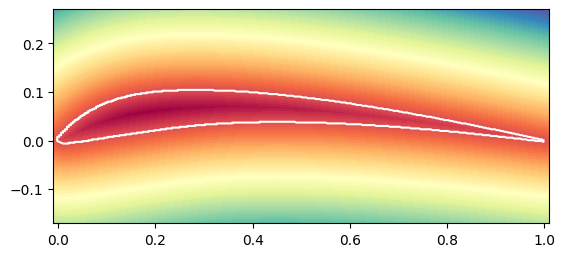

In [ ]:
import pandas as pd
import numpy as np
from shapely.geometry import Point, Polygon
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon
from tqdm import tqdm
from skimage import measure

x_resolution = 256
y_resolution = 256
x_lower_lim = -0.01
x_upper_lim = 1.01
y_lower_lim = -0.17
y_upper_lim = 0.27

def reorder_airfoil_points(x, y):
    # Ensure closed
    if not (np.isclose(x[0], x[-1]) and np.isclose(y[0], y[-1])):
        x = np.r_[x, x[0]]
        y = np.r_[y, y[0]]
        print('not closed')

    i_te = np.argmax(x)
    x = np.roll(x, -i_te)
    y = np.roll(y, -i_te)

    if y[1] < 0:  
        x = np.concatenate([x[:1], x[:0:-1]])
        y = np.concatenate([y[:1], y[:0:-1]])

    return x, y


# --- Load SDF ---
aaa = np.load("sdf_matrix/2032c.dat.npy")


xs = np.linspace(x_lower_lim, x_upper_lim, x_resolution)
ys = np.linspace(y_lower_lim, y_upper_lim, y_resolution)


contours = measure.find_contours(aaa, level=0.0)

# Take largest connected contour = airfoil body
airfoil = max(contours, key=len)

# Convert pixel indices to real coordinates
x_coords = xs[airfoil[:, 1].astype(int)]
y_coords = ys[airfoil[:, 0].astype(int)]


x_sorted, y_sorted = reorder_airfoil_points(x_coords, y_coords)

# Plot
fig, ax = plt.subplots()
ax.contourf(xs, ys, aaa, levels=100, cmap='Spectral')
ax.plot(x_sorted, y_sorted, 'w')

print(x_sorted)
print('hihihihi')
print(y_sorted)
ax.set_aspect('equal', 'box')
plt.show()
